**Check the Python version**

In [ ]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


**Install RDKit**

In [ ]:
!pip install -q rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 27.9 MB/s eta 0:00:00


**Verify RDKit installation**

In [ ]:
import rdkit
print(rdkit.__version__)

2026.03.3


**Install PyTorch Geometric**

In [ ]:
!pip install -q torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.5 MB/s eta 0:00:00


**Verify PyTorch and PyTorch Geometric**

In [ ]:
import torch
import torch_geometric

print(torch.__version__)
print(torch_geometric.__version__)

2.11.0+cpu
2.8.0


**Upload the dataset**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving master_raw_Notebook1.csv to master_raw_Notebook1.csv


**Load the dataset**

In [ ]:
import pandas as pd

data = pd.read_csv("master_raw_Notebook1.csv")

print(data.shape)
print(data.head())
print(data.columns)

(36191, 3)
       SMILES  Label Source
0  O=Cc1ccco1      0  OASIS
1  O=Cc1ccco1      1  OASIS
2  O=Cc1ccco1      0  OASIS
3  O=Cc1ccco1      0  OASIS
4  O=Cc1ccco1      0  OASIS
Index(['SMILES', 'Label', 'Source'], dtype='object')


**Convert SMILES into molecular graphs**

In [ ]:
from rdkit import Chem
from torch_geometric.data import Data
import torch

graphs = []

for _, row in data.iterrows():
    mol = Chem.MolFromSmiles(row["SMILES"])

    if mol is None:
        continue

    # Node features (atomic numbers)
    x = torch.tensor(
        [[atom.GetAtomicNum()] for atom in mol.GetAtoms()],
        dtype=torch.float
    )

    # Edge index
    edge_index = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])

    if len(edge_index) == 0:
        continue

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    y = torch.tensor([row["Label"]], dtype=torch.long)

    graphs.append(Data(x=x, edge_index=edge_index, y=y))

print("Number of graphs:", len(graphs))
print(graphs[0])

[15:28:59] WARNING: not removing hydrogen atom without neighbors
[15:28:59] WARNING: not removing hydrogen atom without neighbors
[15:28:59] WARNING: not removing hydrogen atom without neighbors
[15:28:59] WARNING: not removing hydrogen atom without neighbors
[15:28:59] WARNING: not removing hydrogen atom without neighbors
[15:28:59] WARNING: not removing hydrogen atom without neighbors
[15:28:59] WARNING: not removing hydrogen atom without neighbors
[15:28:59] WARNING: not removing hydrogen atom without neighbors
[15:28:59] WARNING: not removing hydrogen atom without neighbors
[15:28:59] WARNING: not removing hydrogen atom without neighbors
[15:28:59] WARNING: not removing hydrogen atom without neighbors
[15:28:59] WARNING: not removing hydrogen atom without neighbors
[15:28:59] WARNING: not removing hydrogen atom without neighbors
[15:28:59] WARNING: not removing hydrogen atom without neighbors
[15:28:59] WARNING: not removing hydrogen atom without neighbors
[15:28:59] WARNING: not r

Number of graphs: 36136
Data(x=[7, 1], edge_index=[2, 14], y=[1])


**Split the graph dataset**

In [ ]:
from sklearn.model_selection import train_test_split

labels = [g.y.item() for g in graphs]

train_graphs, temp_graphs = train_test_split(
    graphs,
    test_size=0.40,
    stratify=labels,
    random_state=42
)

temp_labels = [g.y.item() for g in temp_graphs]

test_graphs, external_graphs = train_test_split(
    temp_graphs,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

print("Training:", len(train_graphs))
print("Test:", len(test_graphs))
print("External:", len(external_graphs))

Training: 21681
Test: 7227
External: 7228


**Create DataLoaders**

In [ ]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=64, shuffle=False)
external_loader = DataLoader(external_graphs, batch_size=64, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))
print("External batches:", len(external_loader))

Train batches: 339
Test batches: 113
External batches: 113


**Build the Graph Convolutional Network**

In [ ]:
import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.nn import GCNConv, global_mean_pool

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = GCNConv(1, 64)
        self.conv2 = GCNConv(64, 64)
        self.conv3 = GCNConv(64, 64)

        self.fc1 = Linear(64, 32)
        self.fc2 = Linear(32, 1)

    def forward(self, x, edge_index, batch):

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = self.conv3(x, edge_index)
        x = F.relu(x)

        x = global_mean_pool(x, batch)

        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=0.3, training=self.training)

        x = self.fc2(x)

        return x.view(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GCN().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

criterion = torch.nn.BCEWithLogitsLoss()

print(model)
print("Using device:", device)

GCN(
  (conv1): GCNConv(1, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)
Using device: cpu


**Train the GNN**

In [ ]:
train_losses = []
train_accuracies = []

epochs = 30

for epoch in range(epochs):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        output = model(batch.x.float(), batch.edge_index, batch.batch)

        loss = criterion(output, batch.y.float())

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        pred = (torch.sigmoid(output) > 0.5).long()

        correct += (pred == batch.y).sum().item()

        total += batch.y.size(0)

    train_losses.append(total_loss / len(train_loader))
    train_accuracies.append(correct / total)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss: {train_losses[-1]:.4f} | "
        f"Accuracy: {train_accuracies[-1]:.4f}"
    )

Epoch 1/30 | Loss: 0.6328 | Accuracy: 0.6779
Epoch 2/30 | Loss: 0.6298 | Accuracy: 0.6779
Epoch 3/30 | Loss: 0.6296 | Accuracy: 0.6779
Epoch 4/30 | Loss: 0.6297 | Accuracy: 0.6779
Epoch 5/30 | Loss: 0.6290 | Accuracy: 0.6779
Epoch 6/30 | Loss: 0.6292 | Accuracy: 0.6779
Epoch 7/30 | Loss: 0.6292 | Accuracy: 0.6779
Epoch 8/30 | Loss: 0.6290 | Accuracy: 0.6779
Epoch 9/30 | Loss: 0.6285 | Accuracy: 0.6779
Epoch 10/30 | Loss: 0.6287 | Accuracy: 0.6779
Epoch 11/30 | Loss: 0.6288 | Accuracy: 0.6779
Epoch 12/30 | Loss: 0.6285 | Accuracy: 0.6779
Epoch 13/30 | Loss: 0.6282 | Accuracy: 0.6779
Epoch 14/30 | Loss: 0.6281 | Accuracy: 0.6779
Epoch 15/30 | Loss: 0.6281 | Accuracy: 0.6779
Epoch 16/30 | Loss: 0.6280 | Accuracy: 0.6779
Epoch 17/30 | Loss: 0.6281 | Accuracy: 0.6779
Epoch 18/30 | Loss: 0.6282 | Accuracy: 0.6779
Epoch 19/30 | Loss: 0.6279 | Accuracy: 0.6779
Epoch 20/30 | Loss: 0.6281 | Accuracy: 0.6779
Epoch 21/30 | Loss: 0.6279 | Accuracy: 0.6779
Epoch 22/30 | Loss: 0.6277 | Accuracy: 0.67

**Evaluate the test dataset**

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for batch in test_loader:

        batch = batch.to(device)

        output = model(batch.x.float(), batch.edge_index, batch.batch)

        prob = torch.sigmoid(output)

        pred = (prob > 0.5).long()

        y_true.extend(batch.y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())
        y_prob.extend(prob.cpu().numpy())

print("Test Accuracy:", accuracy_score(y_true, y_pred))
print("Test AUC:", roc_auc_score(y_true, y_prob))
print(classification_report(y_true, y_pred))

Test Accuracy: 0.6780130067801301
Test AUC: 0.5376385466090174
              precision    recall  f1-score   support

           0       0.68      1.00      0.81      4900
           1       0.00      0.00      0.00      2327

    accuracy                           0.68      7227
   macro avg       0.34      0.50      0.40      7227
weighted avg       0.46      0.68      0.55      7227



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Evaluate the external validation dataset**

In [ ]:
model.eval()

y_true_ext = []
y_pred_ext = []
y_prob_ext = []

with torch.no_grad():
    for batch in external_loader:

        batch = batch.to(device)

        output = model(batch.x.float(), batch.edge_index, batch.batch)

        prob = torch.sigmoid(output)

        pred = (prob > 0.5).long()

        y_true_ext.extend(batch.y.cpu().numpy())
        y_pred_ext.extend(pred.cpu().numpy())
        y_prob_ext.extend(prob.cpu().numpy())

print("External Accuracy:", accuracy_score(y_true_ext, y_pred_ext))
print("External AUC:", roc_auc_score(y_true_ext, y_prob_ext))
print(classification_report(y_true_ext, y_pred_ext))

External Accuracy: 0.6779192030990592
External AUC: 0.5332952871870398
              precision    recall  f1-score   support

           0       0.68      1.00      0.81      4900
           1       0.00      0.00      0.00      2328

    accuracy                           0.68      7228
   macro avg       0.34      0.50      0.40      7228
weighted avg       0.46      0.68      0.55      7228



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Save the trained GNN model**

In [ ]:
import os

os.makedirs("/content/drive/MyDrive/Notebook7_Output", exist_ok=True)

torch.save(model.state_dict(),
           "/content/drive/MyDrive/Notebook7_Output/GNN_Model.pth")

print("GNN model saved successfully!")

GNN model saved successfully!


**Plot the ROC curve (Test Set)**

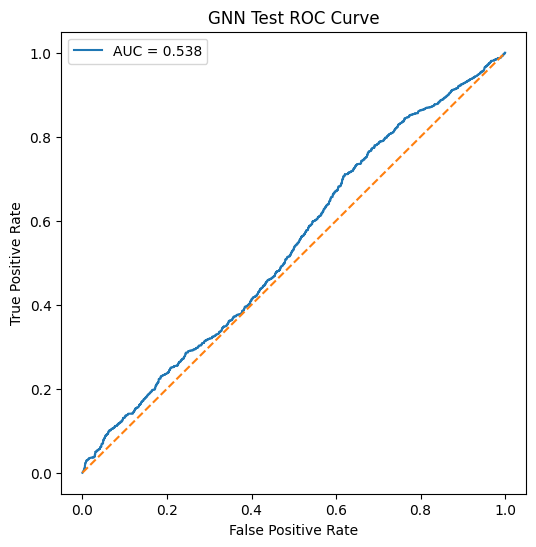

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("GNN Test ROC Curve")
plt.legend()

plt.savefig(
    "/content/drive/MyDrive/Notebook7_Output/GNN_Test_ROC.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Plot the ROC curve (External Validation)**

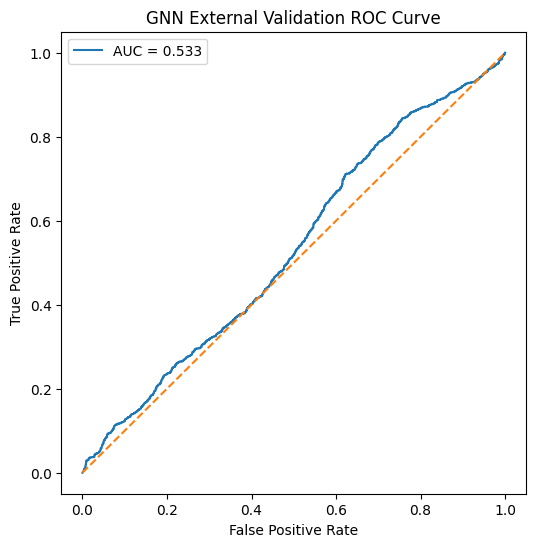

In [ ]:
fpr_ext, tpr_ext, _ = roc_curve(y_true_ext, y_prob_ext)
roc_auc_ext = roc_auc_score(y_true_ext, y_prob_ext)

plt.figure(figsize=(6,6))
plt.plot(fpr_ext, tpr_ext,
         label=f"AUC = {roc_auc_ext:.3f}")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("GNN External Validation ROC Curve")
plt.legend()

plt.savefig(
    "/content/drive/MyDrive/Notebook7_Output/GNN_External_ROC.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Plot the test confusion matrix**

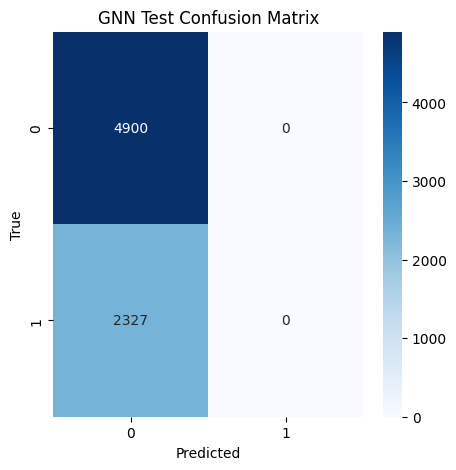

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("GNN Test Confusion Matrix")

plt.savefig(
    "/content/drive/MyDrive/Notebook7_Output/GNN_Test_CM.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Plot the external validation confusion matrix**

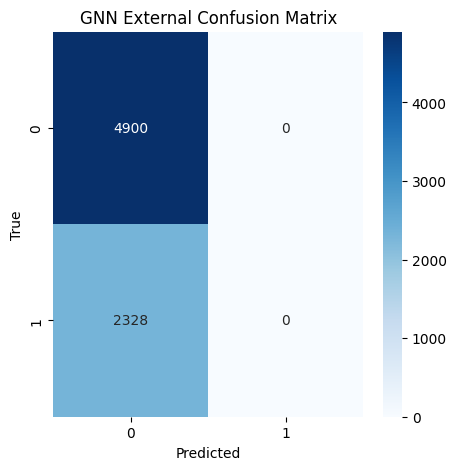

In [ ]:
cm_ext = confusion_matrix(y_true_ext, y_pred_ext)

plt.figure(figsize=(5,5))
sns.heatmap(cm_ext,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("GNN External Confusion Matrix")

plt.savefig(
    "/content/drive/MyDrive/Notebook7_Output/GNN_External_CM.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Initialize training history**

In [ ]:
train_losses = []
train_accuracies = []

**Generate the classification report**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.68      1.00      0.81      4900
           1       0.00      0.00      0.00      2327

    accuracy                           0.68      7227
   macro avg       0.34      0.50      0.40      7227
weighted avg       0.46      0.68      0.55      7227



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Calculate the ROC-AUC score**

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_true, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.5376385466090174


**Calculate the PR-AUC score**

In [ ]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_true, y_prob)

print("PR-AUC:", pr_auc)

PR-AUC: 0.3549740298267502


**Plot the Precision–Recall curve**

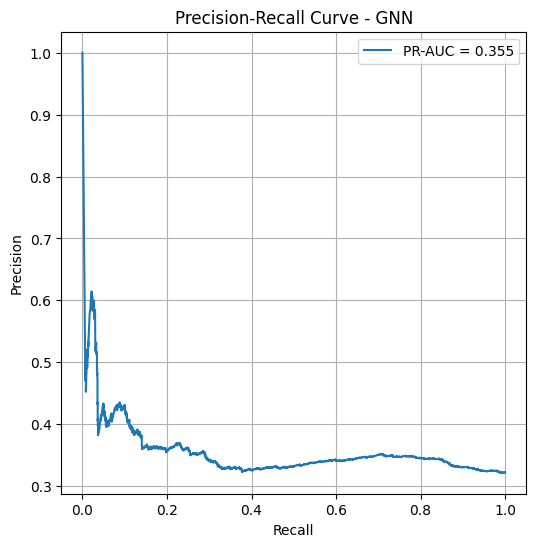

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(6,6))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - GNN")
plt.legend()
plt.grid(True)

plt.show()

**Check prediction object types**

In [ ]:
print(type(y_true))
print(type(y_pred))
print(type(y_prob))

<class 'list'>
<class 'list'>
<class 'list'>


**Plot another ROC Curve**

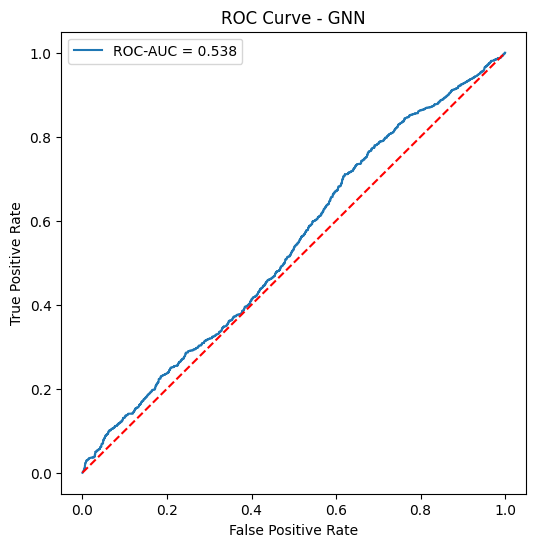

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - GNN")
plt.legend()
plt.show()

**Verify the output folder**

In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive/Notebook7_Output"))

True


**List saved files**

In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/Notebook7_Output"))

['GNN_External_CM.png', 'GNN_Test_ROC.png', 'GNN_Model.pth', 'GNN_External_ROC.png', 'GNN_Test_CM.png']


**Display graph objects**

In [ ]:
print([x for x in globals().keys() if "graph" in x.lower()])

['graphs', 'train_graphs', 'temp_graphs', 'test_graphs', 'external_graphs']


**Save graph datasets**

In [ ]:
import torch

torch.save(train_graphs, "/content/drive/MyDrive/Notebook7_Output/train_graphs.pt")
torch.save(test_graphs, "/content/drive/MyDrive/Notebook7_Output/test_graphs.pt")
torch.save(external_graphs, "/content/drive/MyDrive/Notebook7_Output/external_graphs.pt")

print("Graphs saved successfully!")

Graphs saved successfully!


**Verify saved graph datasets**

In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/Notebook7_Output"))

['GNN_External_CM.png', 'GNN_Test_ROC.png', 'GNN_Model.pth', 'GNN_External_ROC.png', 'test_graphs.pt', 'GNN_Test_CM.png', 'train_graphs.pt', 'external_graphs.pt']


**Locate the saved graph files**

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "train_graphs.pt" in files:
        print(root)

/content/drive/MyDrive/Notebook7_Output


**Display output directory contents**

In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/Notebook7_Output"))

['GNN_External_CM.png', 'GNN_Test_ROC.png', 'GNN_Model.pth', 'GNN_External_ROC.png', 'test_graphs.pt', 'GNN_Test_CM.png', 'train_graphs.pt', 'external_graphs.pt']


**Install PyTorch Geometric**

In [ ]:
!pip install -q torch-geometric

**Import GNNExplainer**

In [ ]:
import torch
from torch_geometric.explain import Explainer, GNNExplainer

**Initialize the GNNExplainer**

In [ ]:
model.eval()

explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=100),
    explanation_type="model",
    node_mask_type="attributes",
    edge_mask_type="object",
    model_config=dict(
        mode="binary_classification",
        task_level="graph",
        return_type="raw",
    ),
)

print("Explainer initialized.")

Explainer initialized.


**Generate an explanation**

In [ ]:
graph = test_graphs[0].to(device)

explanation = explainer(
    x=graph.x,
    edge_index=graph.edge_index,
    batch=graph.batch,
)

print(explanation)

Explanation(node_mask=[8, 1], edge_mask=[16], prediction=[1], target=[1], x=[8, 1], edge_index=[2, 16])


**Plot node importance**

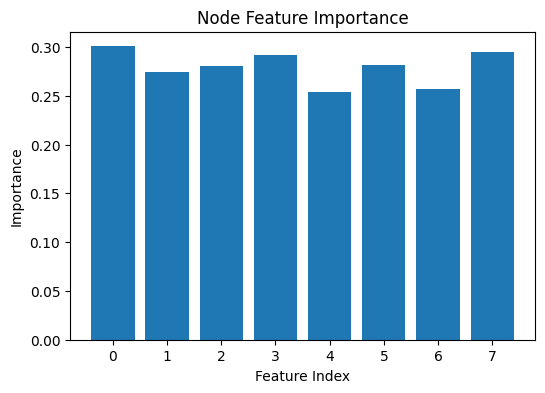

In [ ]:
import matplotlib.pyplot as plt

# Plot feature importance
plt.figure(figsize=(6,4))
plt.bar(range(explanation.node_mask.shape[0]),
        explanation.node_mask.squeeze().cpu().detach().numpy())
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Node Feature Importance")
plt.show()

Plot edge importance

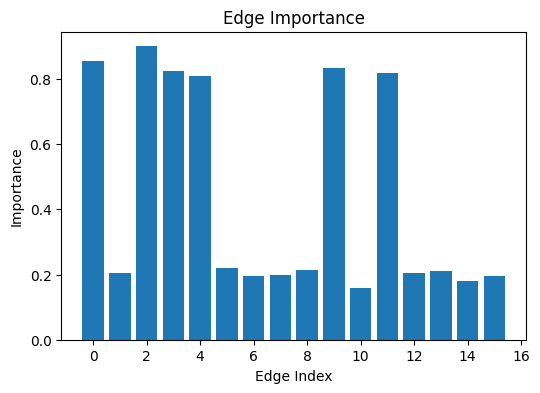

In [ ]:
edge_importance = explanation.edge_mask.cpu().detach().numpy()

plt.figure(figsize=(6,4))
plt.bar(range(len(edge_importance)), edge_importance)
plt.xlabel("Edge Index")
plt.ylabel("Importance")
plt.title("Edge Importance")
plt.show()